# CompCars Web-Nature (Showroom) Fine-Grained Classification
## Transfer Learning with EfficientNetB0 (Using Bounding Box Cropping)
This notebook trains an **EfficientNetB0** model on the **CompCars Web-Nature (Showroom/Catalog)** dataset across 431 benchmark car models.
Images are cropped using the official annotated **bounding boxes** (`label/` directory) before resizing and augmentation, focusing the model purely on the vehicle and removing background clutter.


### 1. Imports & Environment Setup


In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")

for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

I0000 00:00:1788923637.102250  982087 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788923637.133887  982087 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788923638.113304  982087 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
import os
from scipy.io import loadmat
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import Sequence, to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


### 2. Dataset Paths & Class Metadata (431 Benchmark Models)


In [3]:
DATA_DIR = "../../../../dataset_Source/"
IMG_DIR = os.path.join(DATA_DIR, "image")
LABEL_DIR = os.path.join(DATA_DIR, "label")
SPLIT_DIR = os.path.join(DATA_DIR, "train_test_split", "classification")

# Load make and model names metadata
meta = loadmat(os.path.join(DATA_DIR, "misc", "make_model_name.mat"), simplify_cells=True)
make_names = meta["make_names"]    # 163 makes
model_names = meta["model_names"]  # 2004 models


In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load official train and test splits to extract the 431 benchmark models
with open(os.path.join(SPLIT_DIR, "train.txt"), "r") as f:
    train_lines = [l.strip() for l in f if l.strip()]

with open(os.path.join(SPLIT_DIR, "test.txt"), "r") as f:
    test_lines = [l.strip() for l in f if l.strip()]

# Extract unique model IDs used in the classification benchmark
unique_models = sorted(list(set(int(l.split("/")[1]) for l in train_lines)))
NUM_CLASSES = len(unique_models)  # 431 models

# Map 1-based model_id to 0-based sequential class index [0 .. 430]
model_to_label = {model_id: idx for idx, model_id in enumerate(unique_models)}
label_to_model = {idx: model_id for idx, model_id in enumerate(unique_models)}

# Human-readable class names for the 431 models
class_names = [model_names[m - 1] for m in unique_models]

print(f"Total Benchmark Classes: {NUM_CLASSES}")
print("Sample class names (first 10):")
for i in range(10):
    print(f"  Class {i} (model_id {label_to_model[i]}): {class_names[i]}")


Total Benchmark Classes: 431
Sample class names (first 10):
  Class 0 (model_id 1): Audi A3 hatchback
  Class 1 (model_id 2): Audi A4L
  Class 2 (model_id 3): Audi A6L
  Class 3 (model_id 4): Audi Q3
  Class 4 (model_id 5): Audi Q5
  Class 5 (model_id 11): Audi A3 sedan
  Class 6 (model_id 19): Audi A1
  Class 7 (model_id 21): Audi A4 estate
  Class 8 (model_id 22): Audi A5 convertible
  Class 9 (model_id 23): Audi A5 coupe


### 3. Load Training Dataset with Bounding Boxes


In [5]:
rows = []
for rel_path in train_lines:
    parts = rel_path.split("/")
    make_id = int(parts[0])
    model_id = int(parts[1])
    year = parts[2]
    image_name = parts[3]

    # Parse bounding box and viewpoint from corresponding label file
    label_file = os.path.join(LABEL_DIR, os.path.splitext(rel_path)[0] + ".txt")
    with open(label_file, "r") as lf:
        lbl_lines = lf.readlines()
    
    viewpoint = int(lbl_lines[0].strip())
    x1, y1, x2, y2 = [int(v) for v in lbl_lines[2].strip().split()]

    rows.append({
        "image": image_name,
        "make_id": make_id,
        "model_id": model_id,
        "make_name": make_names[make_id - 1],
        "class_name": model_names[model_id - 1],
        "label": model_to_label[model_id],
        "viewpoint": viewpoint,
        "bbox_x1": x1,
        "bbox_y1": y1,
        "bbox_x2": x2,
        "bbox_y2": y2,
        "file_path": os.path.join(IMG_DIR, rel_path)
    })

df = pd.DataFrame(rows)
print(f"Total training images: {len(df)}")
df.head()


Total training images: 16016


,image,make_id,model_id,make_name,class_name,label,viewpoint,bbox_x1,bbox_y1,bbox_x2,bbox_y2,file_path
0,439374a1456969.jpg,78,1,Audi,Audi A3 hatchback,0,1,131,111,765,568,../../../../dataset_Source/image/78/1/2010/439...
1,6c5730eb35dbfc.jpg,78,1,Audi,Audi A3 hatchback,0,1,154,102,752,510,../../../../dataset_Source/image/78/1/2010/6c5...
2,a2b9bfe21409f4.jpg,78,1,Audi,Audi A3 hatchback,0,1,162,130,771,589,../../../../dataset_Source/image/78/1/2014/a2b...
3,043602fa21a621.jpg,78,1,Audi,Audi A3 hatchback,0,1,151,109,763,580,../../../../dataset_Source/image/78/1/2013/043...
4,ccc640bfa095e3.jpg,78,1,Audi,Audi A3 hatchback,0,1,160,129,745,555,../../../../dataset_Source/image/78/1/2012/ccc...


In [6]:
df["class_name"].value_counts().describe()


count    431.000000
mean      37.160093
std       21.396259
min       10.000000
25%       20.000000
50%       31.000000
75%       50.000000
max      143.000000
Name: count, dtype: float64

### 4. Model Architecture: EfficientNetB0 + Classification Head


In [7]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = True
for layer in base_model.layers[:-5]:
    layer.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(NUM_CLASSES, dtype="float32", activation="softmax")
])


I0000 00:00:1788923641.004002  982087 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21728 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


In [8]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [9]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 431)            │       552,111 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,601,682 (17.55 MB)

 Trainable params: 1,333,551 (5.09 MB)

 Non-trainable params: 3,268,131 (12.47 MB)

### 5. Train / Validation Split (Stratified 80/20)


In [10]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)
print(f"Training images: {len(train_df)}")
print(f"Validation images: {len(val_df)}")


Training images: 12812
Validation images: 3204


In [11]:
train_df.head()


,image,make_id,model_id,make_name,class_name,label,viewpoint,bbox_x1,bbox_y1,bbox_x2,bbox_y2,file_path
9401,3395a289fb2fca.jpg,131,1015,Infiniti,Infiniti QX70,236,4,120,118,830,585,../../../../dataset_Source/image/131/1015/2010...
5209,5a67d76e9d7553.jpg,73,441,Volkswagen,Passat,127,4,64,182,831,541,../../../../dataset_Source/image/73/441/2014/5...
7638,c2c0d4fb663b09.jpg,53,765,Cadillac,Cadillac CTS,187,5,71,130,849,593,../../../../dataset_Source/image/53/765/2010/c...
13159,dd044438c4a5ca.jpg,162,1637,MAZDA,Axela sedan,344,3,76,256,834,502,../../../../dataset_Source/image/162/1637/2014...
2751,88beffdacf8698.jpg,54,194,Buck,Exclle,55,2,230,207,677,563,../../../../dataset_Source/image/54/194/2011/8...


In [12]:
val_df.head()


,image,make_id,model_id,make_name,class_name,label,viewpoint,bbox_x1,bbox_y1,bbox_x2,bbox_y2,file_path
10881,53cc0da7b59b3f.jpg,158,1258,Citroen,Citroen C4L,273,4,68,296,779,624,../../../../dataset_Source/image/158/1258/2013...
598,3dc1fc16892307.jpg,78,26,Audi,Audi A7,11,3,106,255,820,470,../../../../dataset_Source/image/78/26/2013/3d...
10681,ced84c577063b1.jpg,158,1251,Citroen,c-Elysee sedan,268,5,116,152,792,584,../../../../dataset_Source/image/158/1251/2010...
7020,c9ee47eda83ea2.jpg,134,661,FIAT,FIAT 500,176,5,63,171,844,626,../../../../dataset_Source/image/134/661/2009/...
1467,5d1663e0bfd99d.jpg,81,100,BWM,BWM 6 Series,29,1,155,109,750,601,../../../../dataset_Source/image/81/100/2013/5...


### 6. Bounding Box Cropping, Data Augmentation & Generators


In [13]:
class BBoxDataGenerator(Sequence):
    """
    Custom Keras Sequence Generator that crops each car image according to its
    annotated bounding box coordinates [x1, y1, x2, y2] before resizing,
    augmenting, and feeding into the model.
    """
    def __init__(self, df, batch_size=32, target_size=(224, 224), num_classes=431, datagen=None, shuffle=True):
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.target_size = target_size
        self.num_classes = num_classes
        self.datagen = datagen
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.df))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_df = self.df.iloc[batch_indexes]

        batch_x = []
        batch_y = []

        for _, row in batch_df.iterrows():
            with Image.open(row["file_path"]) as img:
                # 1. Crop to annotated bounding box [x1, y1, x2, y2]
                bbox = (row["bbox_x1"], row["bbox_y1"], row["bbox_x2"], row["bbox_y2"])
                cropped = img.crop(bbox).convert("RGB")
                resized = cropped.resize(self.target_size)
                arr = np.array(resized, dtype=np.float32)

            # 2. Apply augmentation and preprocessing
            if self.datagen is not None:
                arr = self.datagen.random_transform(arr)
                arr = self.datagen.preprocessing_function(arr)
            else:
                arr = preprocess_input(arr)

            batch_x.append(arr)
            batch_y.append(int(row["label"]))

        return np.array(batch_x, dtype=np.float32), to_categorical(batch_y, num_classes=self.num_classes)

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2)
)

train_generator = BBoxDataGenerator(
    df=train_df,
    batch_size=BATCH_SIZE,
    target_size=IMG_SIZE,
    num_classes=NUM_CLASSES,
    datagen=train_datagen,
    shuffle=True
)

val_generator = BBoxDataGenerator(
    df=val_df,
    batch_size=BATCH_SIZE,
    target_size=IMG_SIZE,
    num_classes=NUM_CLASSES,
    datagen=None,
    shuffle=False
)


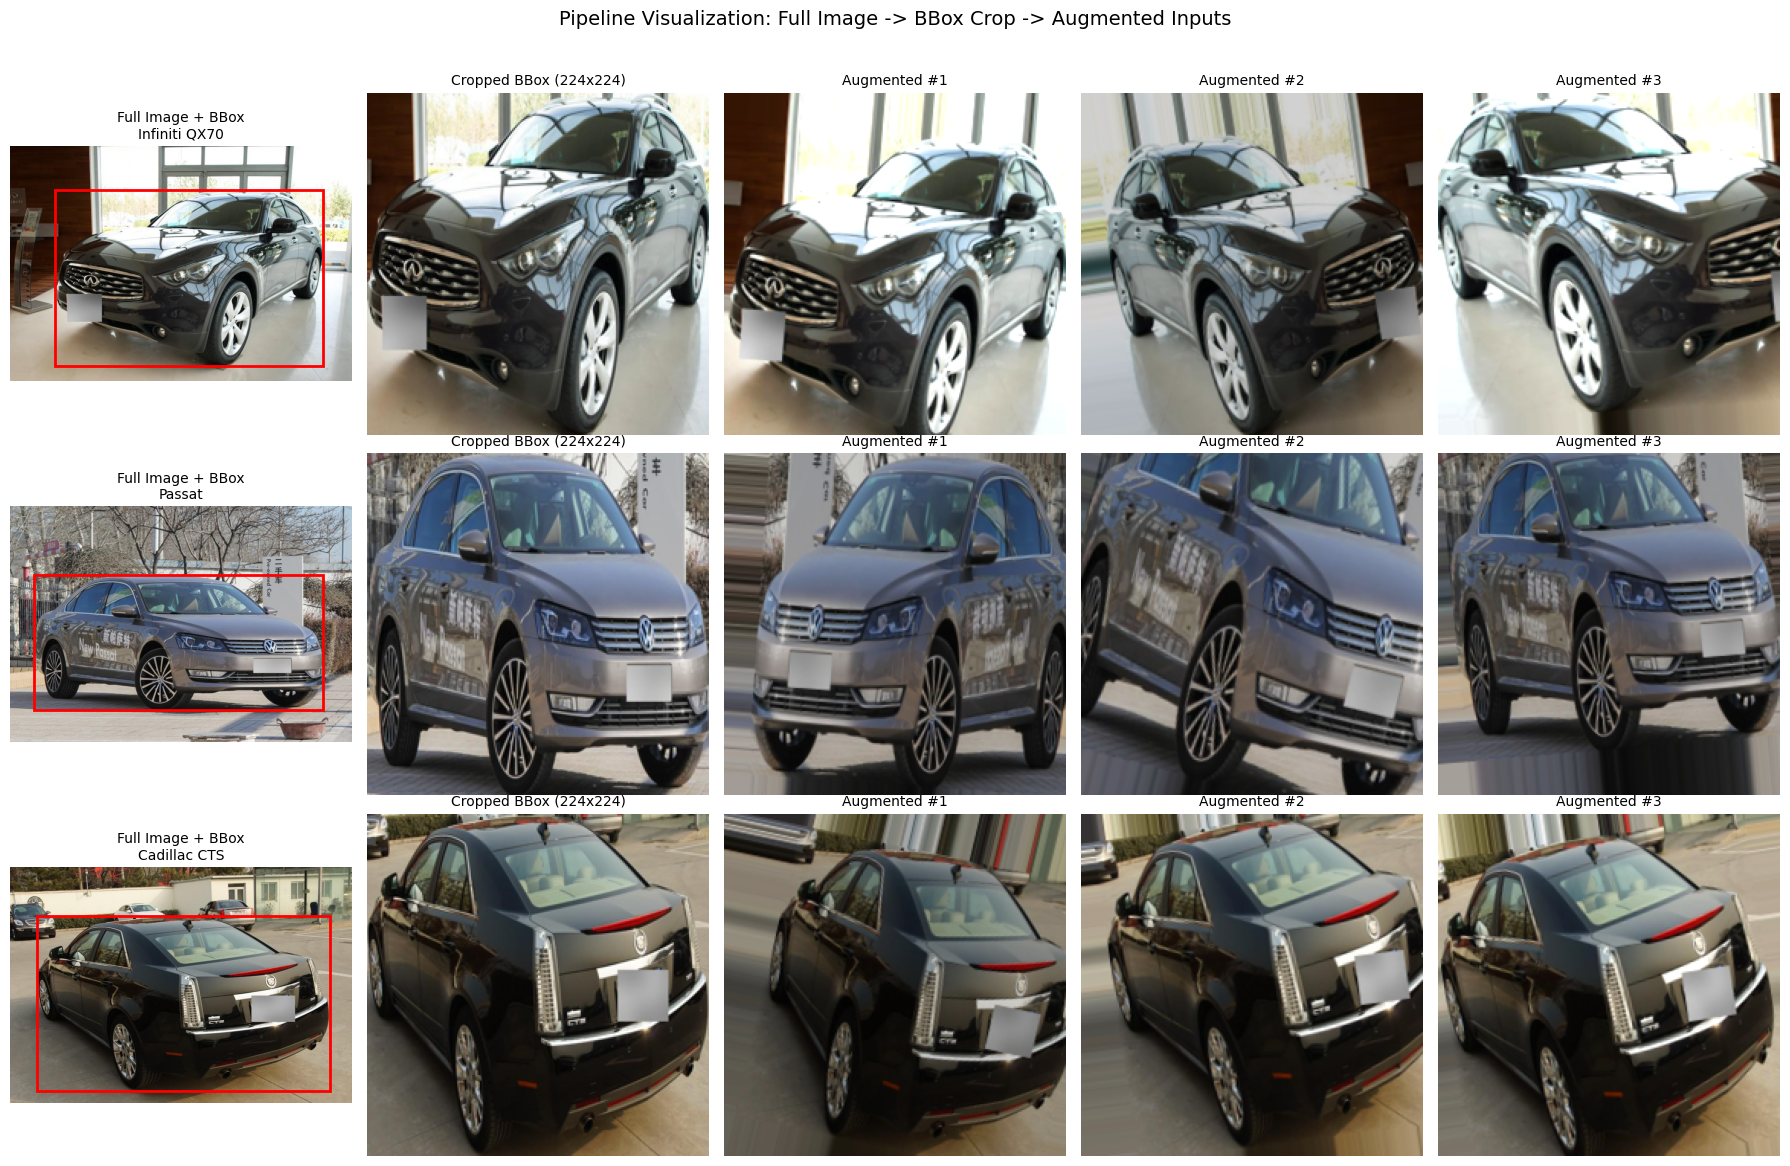

In [14]:
# Visualize Bounding Box Cropping & Augmentations
sample_records = train_df.drop_duplicates(subset=["class_name"]).iloc[:3]
num_samples = len(sample_records)

fig, axes = plt.subplots(num_samples, 5, figsize=(18, 3.8 * num_samples))

for row_idx, (_, row) in enumerate(sample_records.iterrows()):
    with Image.open(row["file_path"]) as full_img:
        full_img_rgb = full_img.convert("RGB")
        # 1. Full Image with bounding box rectangle
        axes[row_idx, 0].imshow(full_img_rgb)
        rect = patches.Rectangle(
            (row["bbox_x1"], row["bbox_y1"]),
            row["bbox_x2"] - row["bbox_x1"],
            row["bbox_y2"] - row["bbox_y1"],
            linewidth=2,
            edgecolor="r",
            facecolor="none"
        )
        axes[row_idx, 0].add_patch(rect)
        axes[row_idx, 0].set_title(f"Full Image + BBox\n{row['class_name']}", fontsize=10)
        axes[row_idx, 0].axis("off")

        # 2. Cropped Bounding Box
        bbox = (row["bbox_x1"], row["bbox_y1"], row["bbox_x2"], row["bbox_y2"])
        cropped_img = full_img_rgb.crop(bbox).resize(IMG_SIZE)
        axes[row_idx, 1].imshow(cropped_img)
        axes[row_idx, 1].set_title("Cropped BBox (224x224)", fontsize=10)
        axes[row_idx, 1].axis("off")

        # 3. Augmented variations on the cropped vehicle
        img_arr = np.array(cropped_img, dtype=np.float32)
        for col_idx in range(2, 5):
            aug_img = train_datagen.random_transform(img_arr.copy())
            aug_display = np.clip(aug_img, 0, 255).astype("uint8")
            axes[row_idx, col_idx].imshow(aug_display)
            axes[row_idx, col_idx].set_title(f"Augmented #{col_idx - 1}", fontsize=10)
            axes[row_idx, col_idx].axis("off")

plt.suptitle("Pipeline Visualization: Full Image -> BBox Crop -> Augmented Inputs", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 7. Callbacks & Model Training


In [15]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=1,
    min_lr=1e-6
)


In [16]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)


/home/researchadmin/Econ/tf-env/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1788923643.544868  982087 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1788923646.675126  982400 service.cc:153] XLA service 0x7dd1b80499d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788923646.675144  982400 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4090, Compute Capability 8.9 (Driver: 13.0.0; Runtime: 12.6.0; Toolkit: 12.5.0; DNN: 9.25.1)
I0000 00:00:1788923646.811084  982400 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788923647.642768  982400 cuda_dnn.cc:461] Loaded cuDNN version 92501
I0000 00:00:1788923647.811736  982400 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16734__.262
E0000 00:00:1788923649.379647  982400 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, 

  1/401 ━━━━━━━━━━━━━━━━━━━━ 1:23:26 13s/step - accuracy: 0.0000e+00 - loss: 6.1147

I0000 00:00:1788923656.010527  982400 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


268/401 ━━━━━━━━━━━━━━━━━━━━ 36s 273ms/step - accuracy: 0.0348 - loss: 5.7939

I0000 00:00:1788923730.070733  982397 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16734__.262
E0000 00:00:1788923730.456430  982397 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1788923731.528488  982397 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1788923731.830307  982397 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1788923732.361398  984892 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 80 bytes spill stores, 80 bytes spill loads



401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.0482 - loss: 5.6232

I0000 00:00:1788923772.376530  986261 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_2', 4 bytes spill stores, 4 bytes spill loads

E0000 00:00:1788923789.006237  982397 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1788923789.104256  982397 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1788923789.353572  986475 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_2', 52 bytes spill stores, 52 bytes spill loads

E0000 00:00:1788923790.102092  982397 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight System

401/401 ━━━━━━━━━━━━━━━━━━━━ 149s 342ms/step - accuracy: 0.0899 - loss: 5.1243 - val_accuracy: 0.2512 - val_loss: 3.7998 - learning_rate: 0.0010
Epoch 2/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 121s 303ms/step - accuracy: 0.3163 - loss: 3.2940 - val_accuracy: 0.4632 - val_loss: 2.4758 - learning_rate: 0.0010
Epoch 3/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 130s 325ms/step - accuracy: 0.5027 - loss: 2.2643 - val_accuracy: 0.5593 - val_loss: 1.8744 - learning_rate: 0.0010
Epoch 4/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 149s 371ms/step - accuracy: 0.6175 - loss: 1.6747 - val_accuracy: 0.6292 - val_loss: 1.5265 - learning_rate: 0.0010
Epoch 5/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 135s 337ms/step - accuracy: 0.6832 - loss: 1.3288 - val_accuracy: 0.6745 - val_loss: 1.3236 - learning_rate: 0.0010
Epoch 6/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 117s 291ms/step - accuracy: 0.7316 - loss: 1.1052 - val_accuracy: 0.6913 - val_loss: 1.2477 - learning_rate: 0.0010
Epoch 7/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 118s 295ms/step - accuracy: 0.7706 

### 8. Save Training History & Visualize Metrics


In [17]:
history_df = pd.DataFrame(history.history)
history_df.head()
history_df.to_csv("compcars_showroom_bbox_efficientnetb0.csv", index=False)


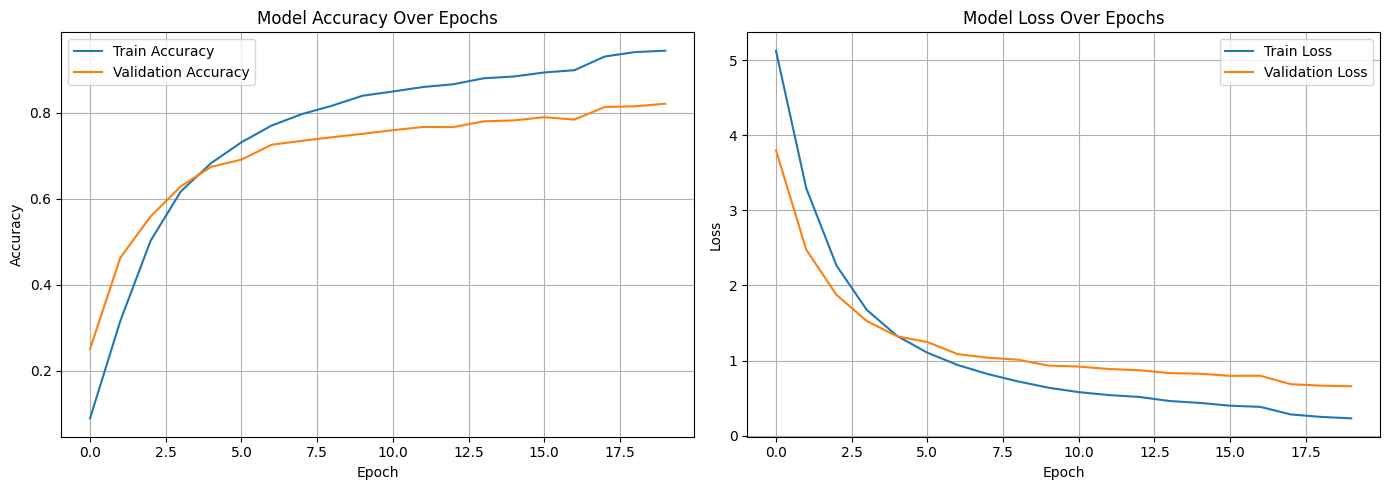

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history_df["accuracy"], label="Train Accuracy")
axes[0].plot(history_df["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Model Accuracy Over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(history_df["loss"], label="Train Loss")
axes[1].plot(history_df["val_loss"], label="Validation Loss")
axes[1].set_title("Model Loss Over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


### 9. Model Evaluation on Official Showroom Test Set (Cropped BBoxes)


In [19]:
test_rows = []
for rel_path in test_lines:
    parts = rel_path.split("/")
    make_id = int(parts[0])
    model_id = int(parts[1])
    image_name = parts[3]

    # Parse bounding box from label file
    label_file = os.path.join(LABEL_DIR, os.path.splitext(rel_path)[0] + ".txt")
    with open(label_file, "r") as lf:
        lbl_lines = lf.readlines()
    
    viewpoint = int(lbl_lines[0].strip())
    x1, y1, x2, y2 = [int(v) for v in lbl_lines[2].strip().split()]

    test_rows.append({
        "image": image_name,
        "make_id": make_id,
        "model_id": model_id,
        "make_name": make_names[make_id - 1],
        "class_name": model_names[model_id - 1],
        "label": model_to_label[model_id],
        "viewpoint": viewpoint,
        "bbox_x1": x1,
        "bbox_y1": y1,
        "bbox_x2": x2,
        "bbox_y2": y2,
        "file_path": os.path.join(IMG_DIR, rel_path)
    })

test_df = pd.DataFrame(test_rows)

test_generator = BBoxDataGenerator(
    df=test_df,
    batch_size=BATCH_SIZE,
    target_size=IMG_SIZE,
    num_classes=NUM_CLASSES,
    datagen=None,
    shuffle=False
)

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")


466/467 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.8374 - loss: 0.5907

E0000 00:00:1788926181.102601  982397 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1788926182.440382  982397 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1788926182.848407  982397 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1788926182.983544 1030478 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_2', 4 bytes spill stores, 4 bytes spill loads



467/467 ━━━━━━━━━━━━━━━━━━━━ 68s 146ms/step - accuracy: 0.8443 - loss: 0.5865
Test loss: 0.5865
Test accuracy: 0.8443


### 10. Save Model and Standard Weights


In [20]:
# Save entire model
model.save("showroom_bbox_b0_finetuned.keras")

# Save standard weights file (.weights.h5)
model.save_weights("showroom_bbox_b0_finetuned.weights.h5")
print("Saved showroom_bbox_b0.keras and showroom_bbox_b0.weights.h5 successfully!")


Saved showroom_bbox_b0.keras and showroom_bbox_b0.weights.h5 successfully!
